### Imports

In [ ]:
import os
import pickle
import gymnasium as gym
from keras import optimizers
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
import argparse
import utils as utils
from make_videos import record_video_from_actor
from concurrent.futures import ThreadPoolExecutor
import ale_py
import numpy as np

# from mods
from model.agent import AgentPPO
from model.actor import Actor
from model.critic import Critic

# Ugnore numpy warnings
import warnings
warnings.filterwarnings("ignore")

### Constants
- Main selections of running constants
- This includes testing, saving, video rendering etc

In [2]:

##
## Main running constants
##
GAME = "ALE/Boxing-v5"
EPOCHSPERCYCLE = 3 # 3
# i.e how many sets of trajectories we sample under one 
CYCLES = 2000
ENVNUM = 10
SOLUTIONTHRESHOLD = 90 
COLLECTIONSIZE = 1787

# plotting stuff
PLOT = True
FIGURENAME = "Box_final"
LATEX = True
DIAGRAMWIDTH = 397.48499
BORDERTHICKNESS = 0.5
LINETHICKNESS = 0.6
STYLE = "latex_style.mplstyle"

# save stuff
SAVE = True
CHECKPOINTS = True
CHECKPOINTFREQ = COLLECTIONSIZE * ENVNUM * 10
actorPath = f"trainedModels/{GAME}{'/x/check/' if CHECKPOINTS else '/x/'}actor_model"
criticPath = f"trainedModels/{GAME}{'/x/check/' if CHECKPOINTS else '/x/'}critic_model"
# actorPath = f"best_model/actor_model"
# criticPath = f"best_model/critic_model"

# test parameters
TESTING = False
TESTFREQ = COLLECTIONSIZE * ENVNUM * 10
RUNSPERTEST = 10

# video parameters (do not touch training hyperparameters)
# Default set to produce 20 periodic snapshots during a 2000-cycle run (2000 / 100 = 20)
VIDEO_FREQ = 100          # record a video every N cycles (cycles counted from 1)
VIDEO_EPISODES = 1        # episodes per recorded video
VIDEO_FPS = 30            # frames per second for output mp4
VIDEO_DIR = "videos/training"
VIDEO_DETERMINISTIC = True  # use argmax (deterministic) actions for videos

# load model
# replace x with the mean score to load different models
loadModel = False
LOADSEEDSONLY = True
# loadPathActor = f'trainedModels/{GAME}/-177/actor_model'
# loadPathCritic = f'trainedModels/{GAME}/-177/critic_model'
loadPathActor = f'../best_model/actor_model'
loadPathCritic = f'../best_model/critic_model'

In [3]:

##
## PPO hyperparameters
# - Threshold to clip gradients by global norm
# - GAE threashold - has some bias variance tradeoff implications
# - NOT EPS GREEDY - this EPSCLIP the clipping threshold 
# - Return discount duh
TDLAMBDA = 0.90
DISCOUNT = 0.99
EPSCLIP = 0.2
GRADNORM = 0.5
ENTROPY = 0.01

# toggles
USEGAE = True
USEADV = False
USEENTROPY = True

# CNN hyperparameters
CONVOLUTIONS = False
ACTORCONVFILTERS = 32
ACTORDENSEUNITS = 256
CRITICCONVFILTERS = 32
CRITICDENSEUNITS = 512

# DONT use more than 100 for any of the attari games itll go OOM (probably)
#(due to parallel envs this will be divided by Num envs so make it divisable)
BATCHSIZE = 64 

### Video Management

In [4]:

video_enabled = True
video_freq = VIDEO_FREQ
video_episodes = VIDEO_EPISODES
video_fps = VIDEO_FPS
video_dir = VIDEO_DIR
video_deterministic = VIDEO_DETERMINISTIC
async_video = True
initial_video = True

executor = ThreadPoolExecutor(max_workers=2) if async_video and video_enabled else None
futures = []

if async_video and video_enabled:
    print(f"Async video recording enabled (saving to {video_dir}, every {video_freq} cycles)")

# Show expected number of videos for this run (initial + periodic + final)
if video_enabled:
    expected_periodic = CYCLES // video_freq if video_freq > 0 else 0
    expected_initial = 1 if initial_video else 0
    expected_total = expected_periodic + expected_initial + 1  # include final
    print(f"Video plan: {expected_initial} initial + {expected_periodic} periodic + 1 final = {expected_total} videos (videos saved to {video_dir})")
else:
    print("Video recording disabled for this run.")

Async video recording enabled (saving to videos/training, every 100 cycles)
Video plan: 1 initial + 20 periodic + 1 final = 22 videos (videos saved to videos/training)


### Game and Class initialisation

In [5]:

# start single env to get dimensions just to make like easier for changing games
env = gym.make(GAME, obs_type ='ram')
observation, info = env.reset()
dimensions = observation.shape
move_total = env.action_space.n   # type: ignore
env.close()
print(f"dims: {dimensions}, action_space: {move_total} ")


actor = Actor(
    dimensions=dimensions, 
    regression=False,
    total_moves=move_total,
    conv = CONVOLUTIONS,
    conv_filters=ACTORCONVFILTERS,
    dense_units=ACTORDENSEUNITS,
    eps_clip=EPSCLIP,
    gradnorm=GRADNORM,
    entropy= ENTROPY
)

critic = Critic(
    dimensions=dimensions, 
    regression=True,
    total_moves=move_total,
    conv = CONVOLUTIONS,
    conv_filters=CRITICCONVFILTERS,
    dense_units=CRITICDENSEUNITS,
    gradnorm=GRADNORM
) 

# agent constructor
agent = AgentPPO(
    d_size = ENVNUM,
    collection_size=COLLECTIONSIZE,
    actor= actor,
    critic= critic,
    discount = DISCOUNT, 
    epsilon = EPSCLIP,
    td_lambda = TDLAMBDA
)



# setup envs to be parallel 
envs = gym.make_vec(GAME, num_envs=ENVNUM, vectorization_mode="async",obs_type = "ram")

# Initialize bestScore for tracking best sample_mean
bestScore = float('-inf')

# optimisers
lr = optimizers.schedules.CosineDecay( initial_learning_rate= 0.0000005 , decay_steps=200000, alpha=0.05, warmup_steps=1000 , warmup_target=0.00025 )

act_opt = optimizers.AdamW(learning_rate = lr) # type: ignore
critic_opt = optimizers.AdamW(learning_rate = lr) # type: ignore

rng = np.random.default_rng()
# seeds stored in matrix, where [game generation seed , the rest -> epoch shuffle seeds]
game_seeds = rng.integers(low=0,high=4000000000, size=(CYCLES,EPOCHSPERCYCLE + 1), dtype=np.uint32)

# try loading models
if loadModel:
    game_seeds = utils.loadModel(agent, loadPathActor, loadPathCritic, act_opt, critic_opt, actor, critic, LOADSEEDSONLY)


dims: (128,), action_space: 18 


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [6]:

# Optional initial pre-training video (cycle 0)
if video_enabled and initial_video:
    os.makedirs(video_dir, exist_ok=True)
    init_out = os.path.join(video_dir, 'train_cycle_0.mp4')
    try:
        if executor:
            fut_init = executor.submit(record_video_from_actor, actor, GAME, init_out, video_episodes, video_fps, video_deterministic, agent.total_steps if 'agent' in locals() else None)
            futures.append(fut_init)
            def _init_done_callback(fut, path=init_out):
                try:
                    fut.result()
                except Exception as exc:
                    print(f"Background initial video task failed: {exc}")
                    import traceback
                    traceback.print_exc()
            fut_init.add_done_callback(_init_done_callback)
            print(f"Submitted async initial video task -> {init_out}")
        else:
            print(f"Recording synchronous initial video -> {init_out}")
            record_video_from_actor(actor, GAME, init_out, episodes=video_episodes, fps=video_fps, deterministic=video_deterministic, seed=None)
    except Exception as e:
        print(f"Failed to record initial video: {e}")
    


Submitted async initial video task -> videos/training/train_cycle_0.mp4
(128,)

### Training
- Note: The mean comes from all terminal returns within a given sampling block (can be a sample size of min N of envs)

In [7]:

##
## Main Training loop
##  
for cycle in range(CYCLES):
    # print(f"\n====================== Cycle {cycle} =========================\n")

    sample_mean, steps, std = agent.train_cycle(
        envs,
        game_seeds[cycle], 
        actor_opt=act_opt,
        critic_opt=critic_opt,
        epoch_num=EPOCHSPERCYCLE,
        batch_size= int(BATCHSIZE / 5 ),
        use_gae = USEGAE,
        use_adv= USEADV,
        use_entropy=USEENTROPY,
    )

    total_updates = ((agent.total_steps/BATCHSIZE) * EPOCHSPERCYCLE)
    # print(f"\n ===>  , total steps this cycle: {steps} ")
    print(f" ===> Steps: {agent.total_steps} | Human Normalised Frames: {agent.total_steps / ENVNUM * 4 } | Sample: {cycle} | GradUpdates: {total_updates:.0f} | lr = {critic_opt.learning_rate:.6f} | Mean Score: {sample_mean:.2f} +/- {std:.2f} | Rolling Mean: {agent.rolling_mean_history[-1]:.2f}")


    if agent.rolling_mean_history[-1] > SOLUTIONTHRESHOLD:
        print(f"Solution Reached (Mean [-50:] = {agent.rolling_mean_history[-1]:.2f})")
        played_cycles = cycle
        break
        
    # if agent.total_steps % TESTFREQ == 0 and agent.total_steps > 0 and TESTING:
    #     # create a vectorized test env (AgentPPO.__collect_data expects a gym.Env with reset())
    #     test_env = gym.make_vec(GAME, num_envs=RUNSPERTEST, vectorization_mode="async", obs_type='ram')
    #     agent.test(test_env, RUNSPERTEST)
    #     test_env.close()
    
    utils.save(
        actorPath, 
        criticPath, 
        CHECKPOINTS, 
        agent, 
        CHECKPOINTFREQ, 
        cycle, 
        agent.rolling_mean_history[-1], 
        act_opt, 
        critic_opt, 
        game_seeds, 
        False, 
        asBest=(bestScore<sample_mean and cycle > CYCLES/2)
    )
    agent.clear_data_store()

    # Update bestScore if current sample_mean is better
    if sample_mean > bestScore:
        bestScore = sample_mean

    # periodic training snapshot video (configurable / async)
    try:
        if video_enabled and (cycle + 1) % video_freq == 0:
            os.makedirs(video_dir, exist_ok=True)
            out_path = os.path.join(video_dir, f'train_cycle_{cycle+1}.mp4')
            if executor:
                fut = executor.submit(record_video_from_actor, agent.actor, GAME, out_path, video_episodes, video_fps, video_deterministic, agent.total_steps)
                futures.append(fut)
                # Attach a callback to report any exceptions from the background task immediately
                def _video_done_callback(fut, cyc=cycle+1, path=out_path):
                    try:
                        fut.result()
                    except Exception as exc:
                        print(f"Background video task failed for cycle {cyc}: {exc}")
                        import traceback
                        traceback.print_exc()
                fut.add_done_callback(_video_done_callback)
                print(f"Submitted async video task for cycle {cycle+1} -> {out_path}")
            else:
                print(f"Recording synchronous video for cycle {cycle+1} -> {out_path}")
                record_video_from_actor(agent.actor, GAME, out_path, episodes=video_episodes, fps=video_fps, deterministic=video_deterministic, seed=agent.total_steps)
    except Exception as e:
        print(f"Failed to record training video for cycle {cycle+1}: {e}")







 ===> Steps: 17870 | Human Normalised Frames: 7148.0 | Sample: 0 | GradUpdates: 838 | lr = 0.000112 | Mean Score: 1.40 +/- 5.04 | Rolling Mean: 0.70
 ===> Steps: 35740 | Human Normalised Frames: 14296.0 | Sample: 1 | GradUpdates: 1675 | lr = 0.000224 | Mean Score: 1.50 +/- 2.58 | Rolling Mean: 0.97
 ===> Steps: 53610 | Human Normalised Frames: 21444.0 | Sample: 2 | GradUpdates: 2513 | lr = 0.000250 | Mean Score: 2.60 +/- 7.21 | Rolling Mean: 1.38
 ===> Steps: 71480 | Human Normalised Frames: 28592.0 | Sample: 3 | GradUpdates: 3351 | lr = 0.000250 | Mean Score: 1.30 +/- 5.46 | Rolling Mean: 1.36
 ===> Steps: 89350 | Human Normalised Frames: 35740.0 | Sample: 4 | GradUpdates: 4188 | lr = 0.000250 | Mean Score: 3.60 +/- 3.23 | Rolling Mean: 1.73
 ===> Steps: 107220 | Human Normalised Frames: 42888.0 | Sample: 5 | GradUpdates: 5026 | lr = 0.000250 | Mean Score: 2.30 +/- 3.44 | Rolling Mean: 1.81
 ===> Steps: 125090 | Human Normalised Frames: 50036.0 | Sample: 6 | GradUpdates: 5864 | lr 

In [12]:

# Save final
if SAVE:
    utils.save(
        actorPath, 
        criticPath, 
        CHECKPOINTS, 
        agent, 
        CHECKPOINTFREQ, 
        cycle, 
        agent.rolling_mean_history[-1], 
        act_opt, 
        critic_opt, 
        game_seeds,
        True,
        asBest=bestScore<sample_mean
    )

    # Update bestScore for final save
    if sample_mean > bestScore:
        bestScore = sample_mean

utils.save_training_state(actorPath, agent, act_opt, critic_opt, game_seeds)

Info: no existing checkpoint dir trainedModels/ALE/x; skipping rename
 Models saved to trainedModels/ALE/Boxing-v5/90/actor_model and trainedModels/ALE/Boxing-v5/90/critic_model 


In [18]:

# Final training video for the last checkpoint
final_out = "videos/training/final_train.mp4"
record_video_from_actor( agent.actor, GAME, final_out, video_episodes, video_fps, video_deterministic, agent.total_steps)

(128,)


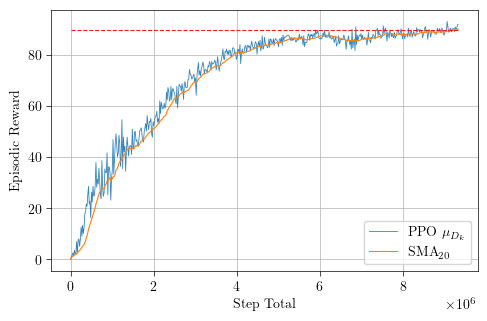

In [ ]:
# plot the trajectory undiscounted return
if PLOT:
    utils.plotGraph(
        BORDERTHICKNESS, 
        LINETHICKNESS, 
        LATEX, 
        STYLE, 
        DIAGRAMWIDTH, 
        SOLUTIONTHRESHOLD, 
        FIGURENAME,
        ENVNUM, 
        agent
    )

In [ ]:
#Final Test
test_mean_store = []
std_store = []

# make sure loading in model we want
loadPathActor = f'trainedModels/ALE/Boxing-v5/90/actor_model'
loadPathCritic = f'trainedModels/ALE/Boxing-v5/90/critic_model'
agent.loadModels(actor_path=loadPathActor, critic_path=loadPathCritic)

# test 100000 steps 
test_mean, test_std, hist = agent.test(env=envs,test_num=50000)

print(len(hist))
print(test_std)
print(np.median(hist))

 Models loaded from trainedModels/ALE/Boxing-v5/90/actor_model and trainedModels/ALE/Boxing-v5/90/critic_model 
 =====> Test Episodes Mean Reward: 89.57830459770115 

[np.float64(96.0), np.float64(98.0), np.float64(96.0), np.float64(94.0), np.float64(89.0), np.float64(84.0), np.float64(89.0), np.float64(85.0), np.float64(79.0), np.float64(85.0), np.float64(98.0), np.float64(94.0), np.float64(96.0), np.float64(89.0), np.float64(94.0), np.float64(88.0), np.float64(96.0), np.float64(100.0), np.float64(97.0), np.float64(94.0), np.float64(87.0), np.float64(86.0), np.float64(98.0), np.float64(77.0), np.float64(81.0), np.float64(98.0), np.float64(86.0), np.float64(88.0), np.float64(84.0), np.float64(96.0), np.float64(98.0), np.float64(85.0), np.float64(100.0), np.float64(100.0), np.float64(98.0), np.float64(98.0), np.float64(98.0), np.float64(100.0), np.float64(89.0), np.float64(89.0), np.float64(92.0), np.float64(84.0), np.float64(80.0), np.float64(83.0), np.float64(86.0), np.float64(84.0), 

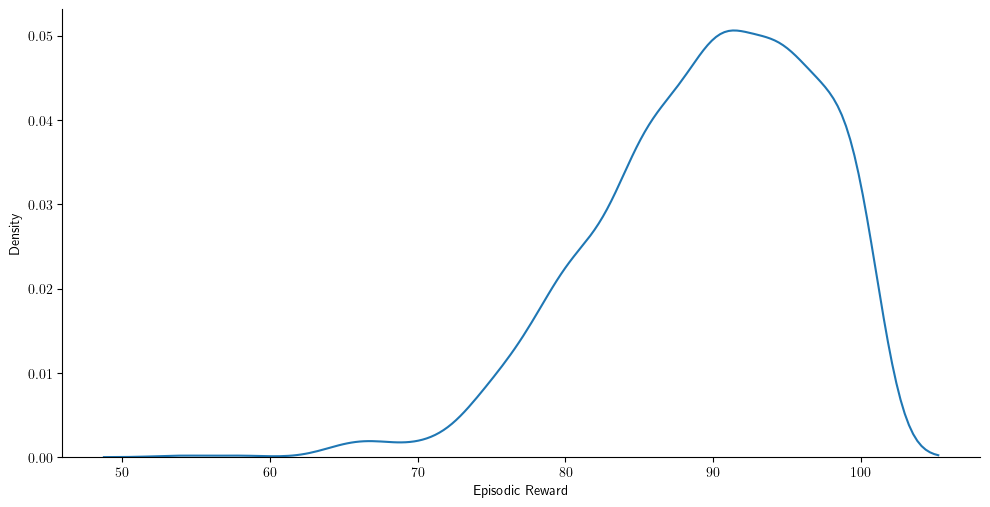

In [16]:
import seaborn as sns
plt.rcParams.update({'text.usetex':True})

sns.displot(
    x = hist,
    kind='kde',
    height = 5,
    aspect = 2
)
plt.xlabel("Episodic Reward")
plt.show()